# NHS A&E Demand Forecasting

## Project Goal
This notebook builds a forecasting model to predict NHS A&E demand using historical provider-level monthly data.

## Objectives
- Load the cleaned multi-year dataset
- Create time-based and lag-based features
- Prepare a modelling dataset
- Train a forecasting model
- Evaluate performance
- Visualise actual vs predicted attendances

In [101]:
# Import necessary libraries
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [102]:
# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [103]:
# Define file paths
processed_folder = "../data/processed"
input_file = os.path.join(processed_folder, "nhs_ae_full_2020_2026.csv")
model_ready_file = os.path.join(processed_folder, "nhs_ae_model_ready_with_features.csv")
predictions_file = os.path.join(processed_folder, "forecast_predictions.csv")
feature_importance_file = os.path.join(processed_folder, "forecast_feature_importance.csv")

In [104]:
# Load processed dataset
df = pd.read_csv(input_file)
df.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,source_file,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate
0,2020-04-01,RCF,NHS ENGLAND NORTH EAST AND YORKSHIRE,AIREDALE NHS FOUNDATION TRUST,2953,182,7,276,0,0,4,0,1006,0,0,287,April-2020-revised-260421-abc123.csv,0.0,0.0,0.0,0.0,0.0,0.0,3142,0.0,276,0.0,4,1293,0.087842,0.0,0.411521
1,2020-05-01,RCF,NHS ENGLAND NORTH EAST AND YORKSHIRE,AIREDALE NHS FOUNDATION TRUST,3858,262,1,304,0,0,0,0,1190,0,0,404,May-2020-revised-260421-de345.csv,0.0,0.0,0.0,0.0,0.0,0.0,4121,0.0,304,0.0,0,1594,0.073769,0.0,0.386799
2,2020-06-01,RCF,NHS ENGLAND NORTH EAST AND YORKSHIRE,AIREDALE NHS FOUNDATION TRUST,4216,309,7,280,0,0,0,0,1314,0,0,467,June-2020-revised-260421-df453.csv,0.0,0.0,0.0,0.0,0.0,0.0,4532,0.0,280,0.0,0,1781,0.061783,0.0,0.392983
3,2020-07-01,RCF,NHS ENGLAND NORTH EAST AND YORKSHIRE,AIREDALE NHS FOUNDATION TRUST,4668,357,16,316,0,0,2,0,1164,0,0,378,July-2020-revised-270421-cd305.csv,0.0,0.0,0.0,0.0,0.0,0.0,5041,0.0,316,0.0,2,1542,0.062686,0.0,0.305892
4,2020-08-01,RCF,NHS ENGLAND NORTH EAST AND YORKSHIRE,AIREDALE NHS FOUNDATION TRUST,4913,332,11,514,0,0,11,0,1266,0,0,357,August-2020-revised-270421-gh920.csv,0.0,0.0,0.0,0.0,0.0,0.0,5256,0.0,514,0.0,11,1623,0.097793,0.0,0.308790


In [105]:
df.shape

(14529, 32)

In [106]:
df.columns.tolist()

['period',
 'org_code',
 'parent_org',
 'org_name',
 'aande_attendances_type_1',
 'aande_attendances_type_2',
 'aande_attendances_other_aande_department',
 'attendances_over_4hrs_type_1',
 'attendances_over_4hrs_type_2',
 'attendances_over_4hrs_other_department',
 'patients_who_have_waited_4_12_hs_from_dta_to_admission',
 'patients_who_have_waited_12plus_hrs_from_dta_to_admission',
 'emergency_admissions_via_aande___type_1',
 'emergency_admissions_via_aande___type_2',
 'emergency_admissions_via_aande___other_aande_department',
 'other_emergency_admissions',
 'source_file',
 'aande_attendances_booked_appointments_type_1',
 'aande_attendances_booked_appointments_type_2',
 'aande_attendances_booked_appointments_other_department',
 'attendances_over_4hrs_booked_appointments_type_1',
 'attendances_over_4hrs_booked_appointments_type_2',
 'attendances_over_4hrs_booked_appointments_other_department',
 'total_attendances',
 'total_booked_attendances',
 'total_over_4hrs',
 'total_booked_over_4hr

In [107]:
# Convert 'period' column to datetime
df["period"] = pd.to_datetime(df["period"])
df["period"].head()

0   2020-04-01
1   2020-05-01
2   2020-06-01
3   2020-07-01
4   2020-08-01
Name: period, dtype: datetime64[ns]

In [108]:
# Check for nulls in critical columns
df[["org_code", "org_name", "period", "total_attendances"]].isnull().sum()

org_code             0
org_name             0
period               0
total_attendances    0
dtype: int64

In [109]:
# Sort for time series
df = df.sort_values(["org_code", "period"]).reset_index(drop=True)
df.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,source_file,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate
0,2020-04-01,8J094,NHS ENGLAND MIDLANDS,BADGER LTD,0,0,58,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,0.0,0.0,0.0,0.0,0.0,0.0,58,0.0,0,0.0,0,0,0.0,0.0,0.0
1,2020-05-01,8J094,NHS ENGLAND MIDLANDS,BADGER LTD,0,0,0,0,0,0,0,0,0,0,0,0,May-2020-revised-260421-de345.csv,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0,0.0,0.0,0.0
2,2020-06-01,8J094,NHS ENGLAND MIDLANDS,BADGER LTD,0,0,0,0,0,0,0,0,0,0,0,0,June-2020-revised-260421-df453.csv,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0,0.0,0.0,0.0
3,2020-07-01,8J094,NHS ENGLAND MIDLANDS,BADGER LTD,0,0,0,0,0,0,0,0,0,0,0,0,July-2020-revised-270421-cd305.csv,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0,0.0,0.0,0.0
4,2020-08-01,8J094,NHS ENGLAND MIDLANDS,BADGER LTD,0,0,0,0,0,0,0,0,0,0,0,0,August-2020-revised-270421-gh920.csv,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0,0.0,0.0,0.0


In [110]:
#
df_model = df.copy()

df_model = df_model[
    (df_model["total_attendances"] > 0)
].copy()

df_model.shape

(13567, 32)

In [111]:
# Check time Coverage
print("Min period:", df_model["period"].min())
print("Max period:", df_model["period"].max())
print("Unique months:", df_model["period"].nunique())
print("Unique organisations:", df_model["org_code"].nunique())

Min period: 2020-04-01 00:00:00
Max period: 2026-02-01 00:00:00
Unique months: 71
Unique organisations: 225


In [112]:
# Create Calendar Features
df_model["year"] = df_model["period"].dt.year
df_model["month"] = df_model["period"].dt.month
df_model["quarter"] = df_model["period"].dt.quarter

In [113]:
# Create cyclical features for month
df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

In [114]:
# Create lag features
df_model["lag_1"] = df_model.groupby("org_code")["total_attendances"].shift(1)
df_model["lag_3"] = df_model.groupby("org_code")["total_attendances"].shift(3)
df_model["lag_6"] = df_model.groupby("org_code")["total_attendances"].shift(6)
df_model["lag_12"] = df_model.groupby("org_code")["total_attendances"].shift(12)

In [115]:
# Create rolling features
df_model["rolling_mean_3"] = (
    df_model.groupby("org_code")["total_attendances"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

df_model["rolling_mean_6"] = (
    df_model.groupby("org_code")["total_attendances"]
    .transform(lambda x: x.shift(1).rolling(6).mean())
)

df_model["rolling_std_3"] = (
    df_model.groupby("org_code")["total_attendances"]
    .transform(lambda x: x.shift(1).rolling(3).std())
)

In [116]:
# Operational features
extra_features = [
    "total_over_4hrs",
    "total_emergency_admissions",
    "total_booked_attendances",
    "total_dta_waits"
]

df_model[extra_features].head()

,total_over_4hrs,total_emergency_admissions,total_booked_attendances,total_dta_waits
0,0,0,0.0,0
71,1464,0,0.0,0
72,777,0,0.0,0
73,776,0,0.0,0
74,722,0,0.0,0


In [117]:
df_model.isnull().sum().sort_values(ascending=False).head(20)

lag_12                                                       2595
lag_6                                                        1324
rolling_mean_6                                               1324
lag_3                                                         668
rolling_std_3                                                 668
rolling_mean_3                                                668
lag_1                                                         225
aande_attendances_type_1                                        0
period                                                          0
org_code                                                        0
parent_org                                                      0
org_name                                                        0
patients_who_have_waited_12plus_hrs_from_dta_to_admission       0
patients_who_have_waited_4_12_hs_from_dta_to_admission          0
attendances_over_4hrs_other_department                          0
attendance

In [118]:
feature_null_cols = [
    "lag_1", "lag_3", "lag_6", "lag_12",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3"
]

df_model = df_model.dropna(subset=feature_null_cols).copy()
df_model.shape

(10972, 44)

In [119]:
# Final Modeling Check
print("Final modelling shape:", df_model.shape)
print("Min period:", df_model["period"].min())
print("Max period:", df_model["period"].max())
print("Unique months:", df_model["period"].nunique())
print("Unique organisations:", df_model["org_code"].nunique())

Final modelling shape: (10972, 44)
Min period: 2021-04-01 00:00:00
Max period: 2026-02-01 00:00:00
Unique months: 59
Unique organisations: 207


In [120]:
# Save model ready dataset
df_model.to_csv(model_ready_file, index=False)
print(f"Saved model-ready dataset to: {model_ready_file}")

Saved model-ready dataset to: ../data/processed/nhs_ae_model_ready_with_features.csv


In [121]:
# Define target and features for modeling
target = "total_attendances"

features = [
    "year",
    "month",
    "quarter",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3",
    "total_over_4hrs",
    "total_emergency_admissions",
    "total_booked_attendances",
    "total_dta_waits"
]

In [122]:
# Final check of features and target
df_model[features + [target]].head()

,year,month,quarter,month_sin,month_cos,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,total_over_4hrs,total_emergency_admissions,total_booked_attendances,total_dta_waits,total_attendances
90,2021,4,2,8.660254e-01,-0.500000,191.0,102.0,155.0,99.0,139.333333,138.833333,46.198846,0,0,0.0,0,155
91,2021,5,2,5.000000e-01,-0.866025,155.0,125.0,147.0,130.0,157.000000,138.833333,33.045423,0,0,0.0,0,180
92,2021,6,2,1.224647e-16,-1.000000,180.0,191.0,113.0,181.0,175.333333,144.333333,18.448125,0,0,0.0,0,255
93,2021,7,3,-5.000000e-01,-0.866025,255.0,155.0,102.0,203.0,196.666667,168.000000,52.041650,0,0,0.0,0,203
94,2021,8,3,-8.660254e-01,-0.500000,203.0,180.0,125.0,189.0,212.666667,184.833333,38.423083,0,0,0.0,0,204


In [123]:
# Time-based train-test split
split_date = pd.Timestamp("2025-04-01")

train = df_model[df_model["period"] < split_date].copy()
test = df_model[df_model["period"] >= split_date].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train period range:", train["period"].min(), "to", train["period"].max())
print("Test period range:", test["period"].min(), "to", test["period"].max())

Train shape: (8966, 44)
Test shape: (2006, 44)
Train period range: 2021-04-01 00:00:00 to 2025-03-01 00:00:00
Test period range: 2025-04-01 00:00:00 to 2026-02-01 00:00:00


In [124]:
# Build X and y
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [125]:
# Train baseline model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,12
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
# Predict
test["prediction"] = model.predict(X_test)
test[["org_code", "org_name", "period", "total_attendances", "prediction"]].head()

,org_code,org_name,period,total_attendances,prediction
137,AAH,TETBURY HOSPITAL TRUST LTD,2025-04-01,536,690.037017
138,AAH,TETBURY HOSPITAL TRUST LTD,2025-05-01,524,579.531086
139,AAH,TETBURY HOSPITAL TRUST LTD,2025-06-01,611,569.276202
140,AAH,TETBURY HOSPITAL TRUST LTD,2025-07-01,688,603.978512
141,AAH,TETBURY HOSPITAL TRUST LTD,2025-08-01,482,679.592133


In [128]:
# Evaluate model performance
mae = mean_absolute_error(y_test, test["prediction"])
rmse = np.sqrt(mean_squared_error(y_test, test["prediction"]))
r2 = r2_score(y_test, test["prediction"])

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

MAE: 414.32
RMSE: 720.91
R²: 0.9942


In [142]:
# Baseline for comparison
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

test["baseline_prediction"] = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, test["baseline_prediction"]))

print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Random Forest RMSE: {rmse:,.2f}")

Baseline RMSE: 802.00
Random Forest RMSE: 720.91


In [129]:
# Add error columns
test["error"] = test["total_attendances"] - test["prediction"]
test["abs_error"] = test["error"].abs()
test["pct_error"] = np.where(
    test["total_attendances"] > 0,
    test["abs_error"] / test["total_attendances"] * 100,
    np.nan
)

test[["org_code", "org_name", "period", "total_attendances", "prediction", "abs_error", "pct_error"]].head()

,org_code,org_name,period,total_attendances,prediction,abs_error,pct_error
137,AAH,TETBURY HOSPITAL TRUST LTD,2025-04-01,536,690.037017,154.037017,28.738249
138,AAH,TETBURY HOSPITAL TRUST LTD,2025-05-01,524,579.531086,55.531086,10.597536
139,AAH,TETBURY HOSPITAL TRUST LTD,2025-06-01,611,569.276202,41.723798,6.828772
140,AAH,TETBURY HOSPITAL TRUST LTD,2025-07-01,688,603.978512,84.021488,12.212426
141,AAH,TETBURY HOSPITAL TRUST LTD,2025-08-01,482,679.592133,197.592133,40.994218


In [130]:
# Over error Summary
test[["abs_error", "pct_error"]].describe()

,abs_error,pct_error
count,2006.000000,2006.000000
mean,414.320308,4.905297
std,590.099365,8.839815
min,0.022992,0.005120
25%,89.928272,1.364136
50%,234.485421,3.005973
75%,522.858242,5.873725
max,8604.571198,270.709998


In [131]:
# Aggregate actual vs predicted by month
monthly_results = (
    test.groupby("period", as_index=False)
    .agg(
        actual_total_attendances=("total_attendances", "sum"),
        predicted_total_attendances=("prediction", "sum")
    )
)

monthly_results["abs_error"] = (
    monthly_results["actual_total_attendances"] -
    monthly_results["predicted_total_attendances"]
).abs()

monthly_results

,period,actual_total_attendances,predicted_total_attendances,abs_error
0,2025-04-01,2204702,2.224795e+06,20093.242173
1,2025-05-01,2298804,2.305488e+06,6684.403383
2,2025-06-01,2257273,2.265041e+06,7767.799868
3,2025-07-01,2308135,2.247890e+06,60245.457888
4,2025-08-01,2170921,2.216022e+06,45101.384184
5,2025-09-01,2215139,2.201182e+06,13956.601771
6,2025-10-01,2305121,2.228767e+06,76353.676372
7,2025-11-01,2252940,2.287279e+06,34339.394988
8,2025-12-01,2230894,2.255026e+06,24131.775078
9,2026-01-01,2226532,2.174448e+06,52083.881832


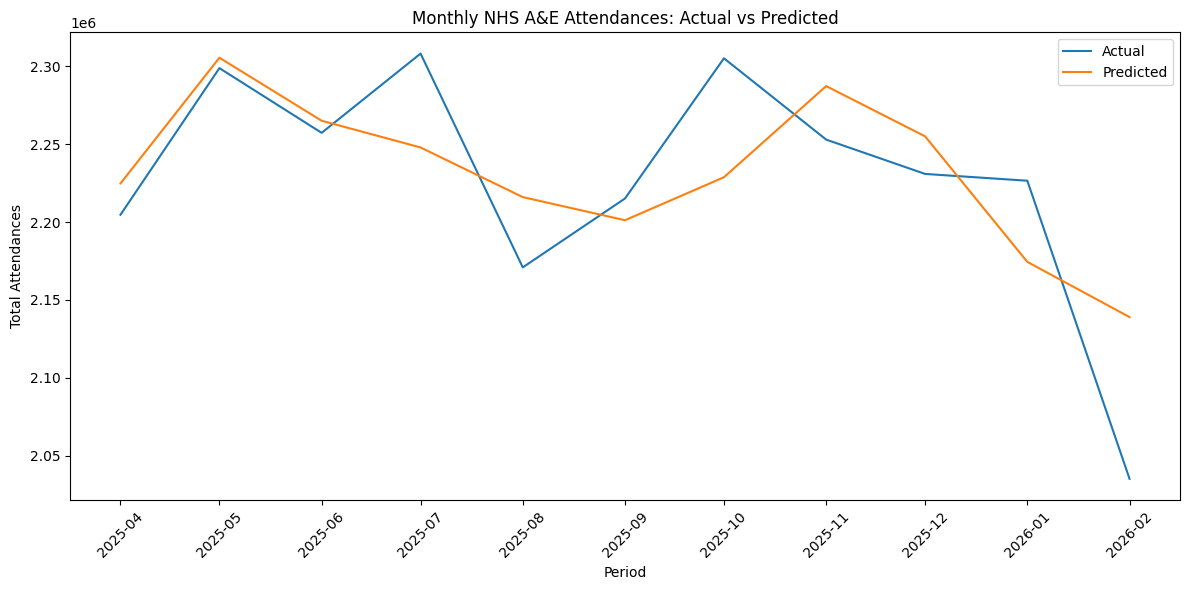

In [132]:
# Plot actual vs predicted monthly totals
plt.figure(figsize=(12, 6))
plt.plot(monthly_results["period"], monthly_results["actual_total_attendances"], label="Actual")
plt.plot(monthly_results["period"], monthly_results["predicted_total_attendances"], label="Predicted")
plt.title("Monthly NHS A&E Attendances: Actual vs Predicted")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

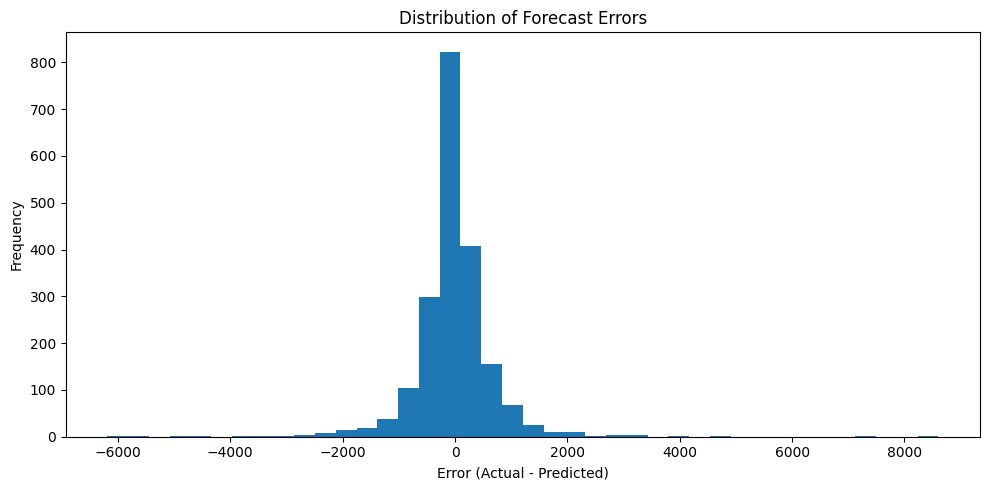

In [133]:
# Plot residuals distribution
plt.figure(figsize=(10, 5))
plt.hist(test["error"], bins=40)
plt.title("Distribution of Forecast Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [143]:
# Feature importance
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
5,lag_1,0.980852
9,rolling_mean_3,0.006751
8,lag_12,0.002096
3,month_sin,0.002060
10,rolling_mean_6,0.001811
11,rolling_std_3,0.001263
13,total_emergency_admissions,0.001025
12,total_over_4hrs,0.000815
14,total_booked_attendances,0.000728
1,month,0.000637


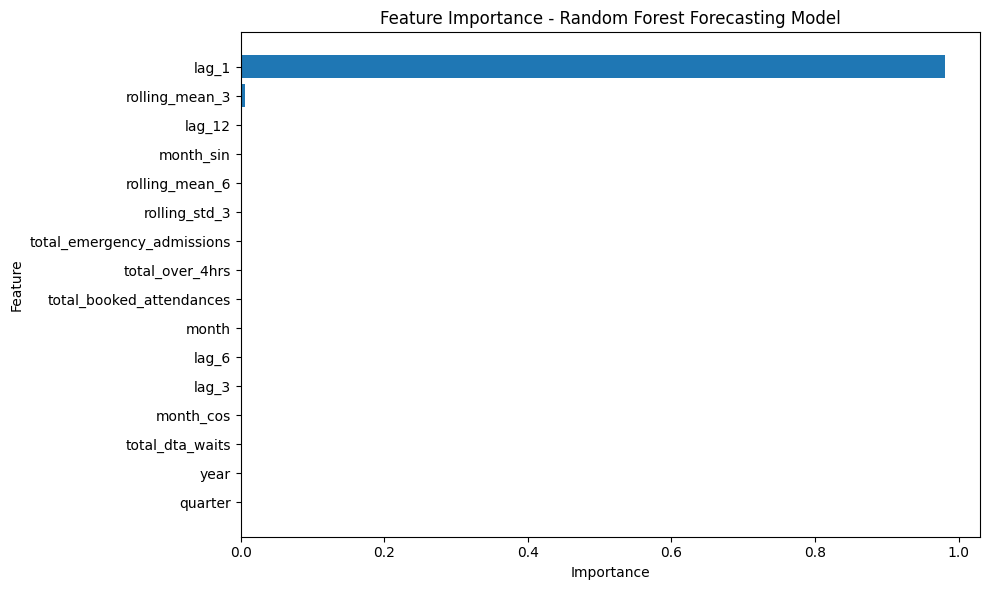

In [135]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.title("Feature Importance - Random Forest Forecasting Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [136]:
# Save predictions
test.to_csv(predictions_file, index=False)
print(f"Saved predictions to: {predictions_file}")

Saved predictions to: ../data/processed/forecast_predictions.csv


In [137]:
# save feature importance
feature_importance.to_csv(feature_importance_file, index=False)
print(f"Saved feature importance to: {feature_importance_file}")

Saved feature importance to: ../data/processed/forecast_feature_importance.csv


In [138]:
# Top best predictions
test.sort_values("abs_error").head(10)[
    ["org_code", "org_name", "period", "total_attendances", "prediction", "abs_error", "pct_error"]
]

,org_code,org_name,period,total_attendances,prediction,abs_error,pct_error
1123,L83087,OKEHAMPTON MEDICAL CENTRE,2025-10-01,88,87.977008,0.022992,0.026127
2033,NNJ13,MELTON MOWBRAY,2025-04-01,64,63.813361,0.186639,0.291624
748,C82038,LATHAM HOUSE MEDICAL PRACTICE,2025-07-01,436,436.251297,0.251297,0.057637
1971,NNJ12,MARKET HARBOROUGH,2026-01-01,106,105.710312,0.289688,0.273290
1121,L83087,OKEHAMPTON MEDICAL CENTRE,2025-08-01,103,103.459298,0.459298,0.445920
13444,RYF,SOUTH WESTERN AMBULANCE SERVICE NHS FOUNDATION...,2025-10-01,1898,1898.590273,0.590273,0.031100
10698,RTQ,GLOUCESTERSHIRE HEALTH AND CARE NHS FOUNDATION...,2025-12-01,7676,7675.224598,0.775402,0.010102
7914,RKB,UNIVERSITY HOSPITALS COVENTRY AND WARWICKSHIRE...,2025-05-01,19983,19981.976838,1.023162,0.005120
5360,RD8,MILTON KEYNES UNIVERSITY HOSPITAL NHS FOUNDATI...,2025-11-01,13700,13701.042085,1.042085,0.007606
6849,RHU,PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST,2025-05-01,14588,14589.131196,1.131196,0.007754


In [139]:
# Top worst predictions
test.sort_values("abs_error", ascending=False).head(10)[
    ["org_code", "org_name", "period", "total_attendances", "prediction", "abs_error", "pct_error"]
]

,org_code,org_name,period,total_attendances,prediction,abs_error,pct_error
12256,RX1,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,2025-10-01,25102,16497.428802,8604.571198,34.278429
7067,RJ2,LEWISHAM AND GREENWICH NHS TRUST,2025-10-01,32807,25398.228289,7408.771711,22.582899
10045,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,2025-08-01,35997,42187.690845,6190.690845,17.197797
10049,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,2025-12-01,36732,42370.813222,5638.813222,15.351228
10549,RTK,ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATIO...,2025-05-01,10512,15504.787959,4992.787959,47.496080
10548,RTK,ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATIO...,2025-04-01,14951,10259.246890,4691.753110,31.380865
10043,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,2025-06-01,37407,41876.144478,4469.144478,11.947348
3326,R1H,BARTS HEALTH NHS TRUST,2025-07-01,45493,41489.126464,4003.873536,8.801076
2980,R0A,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,2025-10-01,42050,38221.941001,3828.058999,9.103589
10048,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,2025-11-01,39127,42872.477943,3745.477943,9.572617


In [140]:
model_path = os.path.join(processed_folder, "rf_forecast_model.joblib")
joblib.dump(model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../data/processed/rf_forecast_model.joblib


## Forecasting Summary

### Model
A Random Forest Regressor was trained to forecast provider-level NHS A&E attendances.

### Features Used
- Calendar features: year, month, quarter
- Seasonal encoding: month_sin, month_cos
- Historical demand: lag_1, lag_3, lag_6, lag_12
- Rolling statistics: rolling_mean_3, rolling_mean_6, rolling_std_3
- Operational activity: over-4-hour waits, emergency admissions, booked attendances, DTA waits

### Evaluation
The model was evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² score

### Value
This extends the project from descriptive SQL analysis into predictive analytics by forecasting future A&E demand using historical provider-level patterns.

## Key Forecasting Insight

The model demonstrates that A&E demand is highly predictable using historical patterns,
with strong dependence on recent months and seasonal trends.

This suggests that short-term forecasting can be effectively used for:
- Workforce planning
- Capacity management
- Resource allocation